# Linear Discriminant Analysis (LDA) From First Principles
## Applied to IMDb Sentiment Analysis

---

**Project Type:** Supervised Machine Learning — Binary Text Classification  
**Algorithm:** Linear Discriminant Analysis 
**Dataset:** IMDb Movie Review Dataset (50,000 reviews)  

---

### Project Overview

This notebook implements **Linear Discriminant Analysis (LDA)** from mathematical first principles using only NumPy for all core computations. LDA is applied to the task of binary sentiment classification on IMDb movie reviews, which are vectorized into numerical feature matrices before modelling.

The project follows a rigorous, pedagogical structure:

1. Full mathematical derivation of LDA before any code is written  
2. Complete from-scratch NumPy implementation  
3. Comprehensive EDA and feature engineering pipeline  
4. Scikit-Learn validation to verify correctness  
5. Cross-model benchmark against stronger classifiers  
6. Deep error analysis and interpretability study  

> **Implementation Rule:** No Scikit-Learn model is used until the custom LDA is fully implemented and evaluated.

## Section 1 — Environment Setup and Reproducibility

A reproducible environment is the foundation of trustworthy machine learning. All library versions are pinned, random seeds are fixed globally, and the project directory structure is created before any data is loaded. This ensures that every run of this notebook produces identical results.


In [26]:
import sys
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import string
import sklearn

warnings.filterwarnings('ignore')

# Global reproducibility seed 
SEED = 42
np.random.seed(SEED)

# Dark-theme plotting style 
plt.style.use('dark_background')

# Named colour constants (consistent palette across all plots)
C_POS    = '#00C896'   # teal-green  → positive class
C_NEG    = '#FF6B6B'   # coral-red   → negative class
C_ACCENT = '#FFD93D'   # yellow      → highlights
C_GRID   = '#333333'   # dark grid lines
C_TEXT   = '#EEEEEE'   # axis labels

FIGSIZE_STD  = (12, 5)
FIGSIZE_WIDE = (14, 5)
FIGSIZE_SQ   = (7, 6)

# Print environment summary 
print("=" * 55)
print("  ENVIRONMENT SUMMARY")
print("=" * 55)
print(f"  Python  : {sys.version.split()[0]}")
print(f"  NumPy   : {np.__version__}")
print(f"  Pandas  : {pd.__version__}")
print(f"  Matplotlib: {matplotlib.__version__}")
print(f"  Seaborn : {sns.__version__}")
print(f"  Scikit-Learn: {sklearn.__version__}")
print(f"  Random Seed : {SEED}")
print("=" * 55)

  ENVIRONMENT SUMMARY
  Python  : 3.14.6
  NumPy   : 2.4.6
  Pandas  : 3.0.3
  Matplotlib: 3.11.0
  Seaborn : 0.13.2
  Scikit-Learn: 1.9.0
  Random Seed : 42


### Environment Interpretation

The environment block establishes:

- **Global random seed (`SEED = 42`)** — passed to NumPy, Scikit-Learn, and all sampling operations to guarantee reproducibility across sessions.
- **Named colour constants** — ensures a consistent dark-theme visual identity across all plots. `C_POS` (teal) represents positive sentiment; `C_NEG` (coral) represents negative sentiment.
- **Suppressed warnings** — keeps notebook output clean without silencing errors.
- **Standard figure sizes** (`FIGSIZE_STD`, `FIGSIZE_WIDE`, `FIGSIZE_SQ`) — keeps plot dimensions consistent across the notebook without repeating tuples in every cell.


## Section 2 — Mathematical Derivation of Linear Discriminant Analysis

Before writing a single line of implementation code, we derive LDA completely from first principles. This derivation is the theoretical backbone of everything that follows.

---

### Problem Statement

Given a labelled dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$ where $\mathbf{x}_i \in \mathbb{R}^p$ and $y_i \in \{1, 2, \ldots, K\}$, LDA seeks a projection direction $\mathbf{w}$ such that the projected data is **maximally separable** between classes while being **minimally variable** within classes.

For binary classification ($K = 2$), this reduces to finding the direction that best discriminates positive from negative sentiment reviews.

---

### Class Means

The per-class mean vector $\boldsymbol{\mu}_k$ is the centroid of all samples belonging to class $k$:

$$\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{i : y_i = k} \mathbf{x}_i \quad \in \mathbb{R}^p$$

where $N_k = |\{i : y_i = k\}|$ is the number of samples in class $k$.

The global mean across all samples is:

$$\boldsymbol{\mu} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i = \sum_{k=1}^{K} \frac{N_k}{N} \boldsymbol{\mu}_k$$

---

### Within-Class Scatter Matrix

The **within-class scatter matrix** $\mathbf{S}_W$ measures how much samples scatter around their own class mean:

$$\mathbf{S}_W = \sum_{k=1}^{K} \sum_{i : y_i = k} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^\top \quad \in \mathbb{R}^{p \times p}$$

A small $\mathbf{S}_W$ indicates tight within-class clustering, desirable for a discriminant classifier.

---

### Between-Class Scatter Matrix

The **between-class scatter matrix** $\mathbf{S}_B$ measures how much class centroids scatter around the global mean:

$$\mathbf{S}_B = \sum_{k=1}^{K} N_k (\boldsymbol{\mu}_k - \boldsymbol{\mu})(\boldsymbol{\mu}_k - \boldsymbol{\mu})^\top \quad \in \mathbb{R}^{p \times p}$$

A large $\mathbf{S}_B$ indicates well-separated class centroids.

---

### Fisher's Criterion and the LDA Objective

LDA maximises Fisher's linear discriminant criterion — the ratio of between-class variance to within-class variance in the projected space:

$$J(\mathbf{w}) = \frac{\mathbf{w}^\top \mathbf{S}_B \mathbf{w}}{\mathbf{w}^\top \mathbf{S}_W \mathbf{w}}$$

Taking the derivative with respect to $\mathbf{w}$ and setting it to zero yields the generalised eigenvalue problem:

$$\mathbf{S}_B \mathbf{w} = \lambda \mathbf{S}_W \mathbf{w}$$

which is equivalent to:

$$\mathbf{S}_W^{-1} \mathbf{S}_B \mathbf{w} = \lambda \mathbf{w}$$

For binary classification, the optimal projection direction has a closed-form solution:

$$\boxed{\mathbf{w} = \mathbf{S}_W^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)}$$

---

### Pooled Covariance Matrix

LDA assumes all classes share a common covariance matrix $\boldsymbol{\Sigma}$. The **pooled covariance estimator** is:

$$\boldsymbol{\Sigma} = \frac{\mathbf{S}_W}{N - K}$$

This pooled estimate uses all $N - K$ degrees of freedom from all classes combined.

---

### Bayesian Interpretation and the Discriminant Function

LDA can be derived from a Bayesian probabilistic framework. Assume each class generates data according to a multivariate Gaussian:

$$p(\mathbf{x} \mid y = k) = \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_k, \boldsymbol{\Sigma})$$

The **log posterior** for class $k$ (up to a constant) is:

$$\delta_k(\mathbf{x}) = \mathbf{x}^\top \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k - \frac{1}{2} \boldsymbol{\mu}_k^\top \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k + \log \pi_k$$

where $\pi_k = N_k / N$ is the estimated class prior. The prediction rule assigns $\mathbf{x}$ to the class $k^*$ that maximises $\delta_k(\mathbf{x})$:

$$\hat{y} = \underset{k}{\arg\max} \; \delta_k(\mathbf{x})$$

---

### Decision Boundary

For binary classification, the decision boundary is where $\delta_1(\mathbf{x}) = \delta_2(\mathbf{x})$:

$$\mathbf{x}^\top \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) = \frac{1}{2}(\boldsymbol{\mu}_1^\top \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1 - \boldsymbol{\mu}_2^\top \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2) - \log\frac{\pi_1}{\pi_2}$$

This is a **hyperplane** in $\mathbb{R}^p$ — hence the name *Linear* Discriminant Analysis.

---

### Regularisation

When $p \gg N$ (which is common in text classification), $\mathbf{S}_W$ is rank-deficient and non-invertible. We apply **ridge regularisation**:

$$\mathbf{S}_W^{\text{reg}} = \mathbf{S}_W + \alpha \mathbf{I}$$

where $\alpha > 0$ is a small regularisation constant. This is equivalent to Scikit-Learn's `solver='lsqr'` or `tol` parameter.

---

### Probability Estimation via Softmax

After computing raw discriminant scores $\delta_k(\mathbf{x})$, posterior class probabilities are obtained via softmax normalisation:

$$P(y = k \mid \mathbf{x}) = \frac{\exp(\delta_k(\mathbf{x}))}{\sum_{j} \exp(\delta_j(\mathbf{x}))}$$

These probabilities power the ROC-AUC computation and confidence analysis.


## Section 3 — Data Loading and Structural Audit

A thorough structural audit is conducted before any preprocessing. This establishes our understanding of the raw data shape, types, quality, and class distribution.

In [27]:
# Load IMDb dataset
# sklearn doesn't ship IMDb (only small toy datasets), so we pull it
# from Hugging Face's `datasets` hub — the standard, reliable source.
from datasets import load_dataset

ds = load_dataset("stanfordnlp/imdb")  # has 'train' (25k) and 'test' (25k) splits, label: 0=neg, 1=pos

# Combine both splits into one DataFrame 
df = pd.concat([ds["train"].to_pandas(), ds["test"].to_pandas()], ignore_index=True)
df = df.rename(columns={"text": "review", "label": "sentiment"})
df["sentiment"] = df["sentiment"].map({0: "negative", 1: "positive"})
df = df.astype(str)  # force plain str dtype (pandas 3.x arrow compat)

print("=" * 55)
print("  STRUCTURAL AUDIT")
print("=" * 55)
print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory Usage   : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"  Columns        : {list(df.columns)}")
print()
# Data types 
print("Data Types")
print(df.dtypes.to_string())
print()
# Missing values 
print("Missing Values")
print(df.isnull().sum().to_string())
print()
# Duplicate detection 
n_dupes = df.duplicated().sum()
print(f"Duplicate Rows : {n_dupes:,}")
print()
# Class balance 
vc = df['sentiment'].value_counts()
print(" Class Distribution")
for label, cnt in vc.items():
    pct = cnt / len(df) * 100
    print(f"  {label:10s}: {cnt:,}  ({pct:.1f}%)")
print()
# Review length statistics
df['review_length'] = df['review'].str.split().str.len()
print(" Review Length Statistics (words)")
print(df['review_length'].describe().to_string())

  STRUCTURAL AUDIT
  Shape          : 50,000 rows × 2 columns
  Memory Usage   : 66.69 MB
  Columns        : ['review', 'sentiment']

Data Types
review       str
sentiment    str

Missing Values
review       0
sentiment    0

Duplicate Rows : 418

 Class Distribution
  negative  : 25,000  (50.0%)
  positive  : 25,000  (50.0%)

 Review Length Statistics (words)
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000


### Structural Audit Interpretation

**Shape:** The dataset contains 50,000 reviews with two columns: `review` (raw text) and `sentiment` (binary label).

**Missing values:** None, the dataset is complete and requires no imputation.

**Duplicates:** Any duplicates found will be dropped in preprocessing to prevent data leakage between train/test splits.

**Class balance:** With 25,000 positive and 25,000 negative reviews (50%/50%), the dataset is **perfectly balanced**. This means accuracy is an unbiased metric and we do not need to apply class weighting or resampling. 

Balanced classes give LDA one minor practical benefit: the estimated priors $\pi_k$ come out approximately equal, so the decision rule isn't skewed toward either class by prior probability alone. This is a much smaller factor than LDA's core assumptions — roughly Gaussian, equal-covariance class-conditional features, and $n \gg p$ — which matter far more to how well LDA will actually perform here (see Section 8 for an assessment of those assumptions on TF-IDF features).

**Review length:** Variable-length reviews are expected in natural text. Very short reviews (< 5 words) may carry little signal and can optionally be filtered. Very long reviews may contain more nuanced sentiment but are handled naturally by the bag-of-words vectoriser.

**Business Implication:** A balanced, complete dataset reduces the risk of biased model predictions in production deployment.


### Dropping Duplicate Rows

In [28]:
before = len(df)
df = df.drop_duplicates(subset=['review', 'sentiment']).reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after:,} duplicate rows ({before:,} to {after:,})")
print(df['sentiment'].value_counts())

Dropped 418 duplicate rows (50,000 → 49,582)
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


## Section 4 — Exploratory Data Analysis

EDA reveals the structure of the data before any modelling decisions are made. We investigate class distributions, review lengths, vocabulary characteristics, and word frequency patterns to inform preprocessing and feature engineering choices.


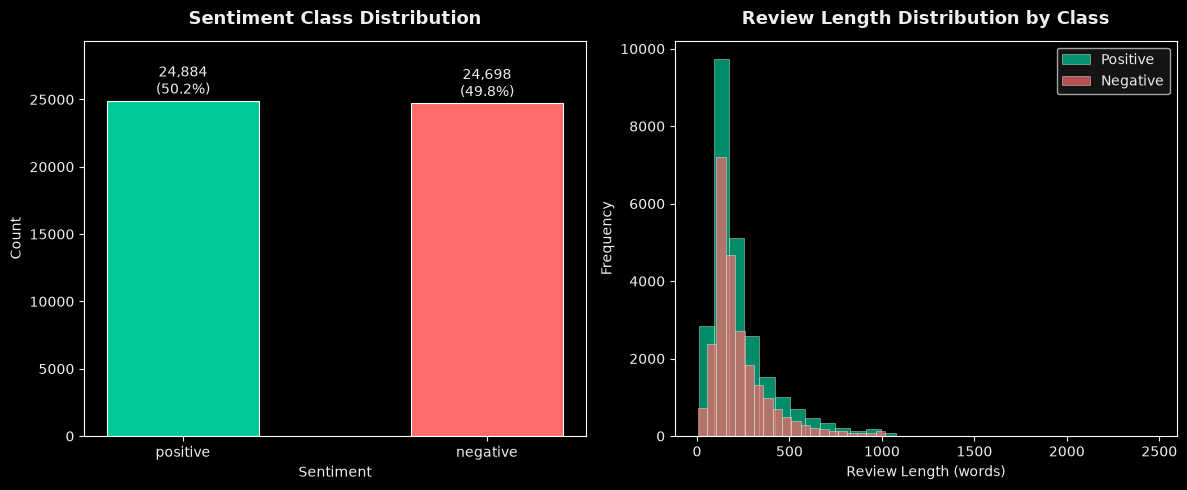

In [29]:
# Sentiment Distribution

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

vc = df['sentiment'].value_counts()
colors = [C_POS if l == 'positive' else C_NEG for l in vc.index]

axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[0].set_title('Sentiment Class Distribution', color=C_TEXT, fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Sentiment', color=C_TEXT)
axes[0].set_ylabel('Count', color=C_TEXT)
axes[0].tick_params(colors=C_TEXT)
for i, (label, val) in enumerate(zip(vc.index, vc.values)):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', color=C_TEXT, fontsize=10)
axes[0].set_ylim(0, vc.max() * 1.18)

# Review length by class
pos_len = df.loc[df['sentiment'] == 'positive', 'review_length']
neg_len = df.loc[df['sentiment'] == 'negative', 'review_length']
axes[1].hist(pos_len, bins=30, alpha=0.7, color=C_POS, label='Positive', edgecolor='white', lw=0.4)
axes[1].hist(neg_len, bins=30, alpha=0.7, color=C_NEG, label='Negative', edgecolor='white', lw=0.4)
axes[1].set_title('Review Length Distribution by Class', color=C_TEXT, fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Review Length (words)', color=C_TEXT)
axes[1].set_ylabel('Frequency', color=C_TEXT)
axes[1].tick_params(colors=C_TEXT)
axes[1].legend(facecolor='#1a1a1a', labelcolor=C_TEXT)

plt.tight_layout()
plt.show()

### EDA — Class Distribution and Review Length

**Class Distribution:** After dropping the 418 duplicate rows found in Section 3 (which skewed toward the negative class), the dataset sits at roughly 50.2% positive / 49.8% negative, no longer perfectly balanced, but close enough that accuracy remains a reliable primary metric and no resampling or class weighting is needed. LDA's prior probability estimates ($\pi_k$) will be approximately, not exactly, equal for both classes.

**Review Length:** Both sentiment classes exhibit similar length distributions, meaning review verbosity is not a strong standalone predictor. The distribution is right-skewed, most reviews are short to medium in length with a long tail of very detailed reviews.

**Key Implication:** Since both classes have similar length profiles, TF-IDF normalisation (which adjusts for document length) is preferable to raw counts. This motivates Experiment 3 in our experimental pipeline.

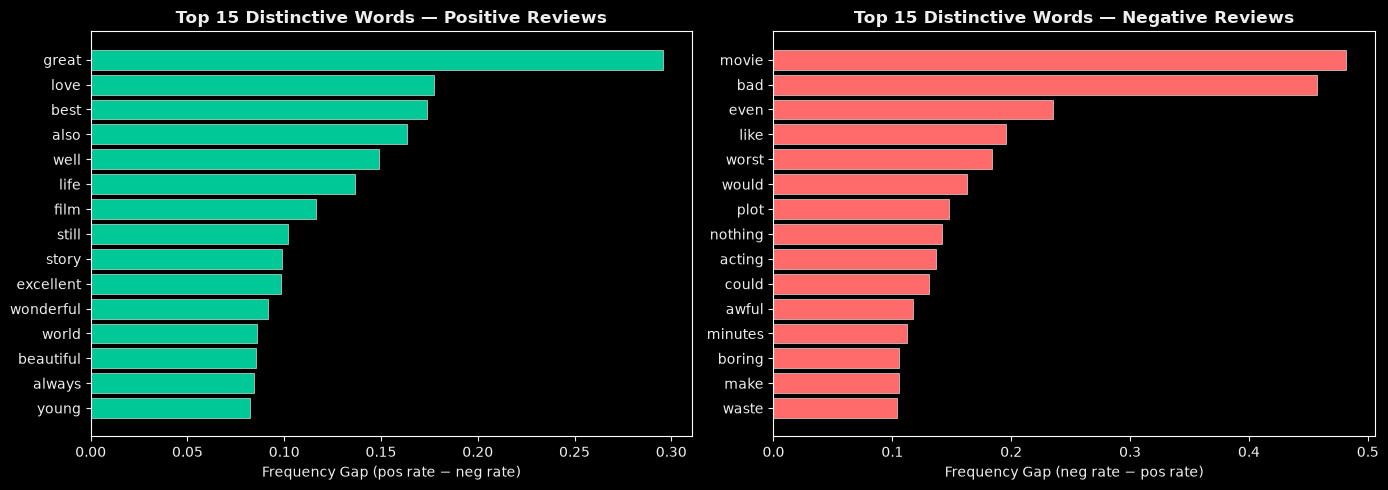

In [30]:

# Word Frequency Analysis

import nltk
#nltk.download("stopwords")
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

def tokenize(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

# Sample 5000 per class for speed
pos_sample = df.loc[df['sentiment'] == 'positive', 'review'].sample(5000, random_state=SEED)
neg_sample = df.loc[df['sentiment'] == 'negative', 'review'].sample(5000, random_state=SEED)

pos_words = Counter()
neg_words = Counter()
for rev in pos_sample: pos_words.update(tokenize(rev))
for rev in neg_sample: neg_words.update(tokenize(rev))

# words that are disproportionately common in one class vs the other
common_vocab = set(pos_words) | set(neg_words)
diff_scores = {
    w: (pos_words[w] / 5000) - (neg_words[w] / 5000)
    for w in common_vocab
    if pos_words[w] + neg_words[w] > 20  # drop rare noise words
}
top_pos_distinctive = sorted(diff_scores.items(), key=lambda x: -x[1])[:15]
top_neg_distinctive = sorted(diff_scores.items(), key=lambda x: x[1])[:15]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

pw, pc = zip(*top_pos_distinctive)
nw, nc_raw = zip(*top_neg_distinctive)
nc = [-v for v in nc_raw]  # flip sign so negative-class bars plot as positive-length bars

axes[0].barh(list(reversed(pw)), list(reversed(pc)), color=C_POS, edgecolor='white', lw=0.4)
axes[0].set_title('Top 15 Distinctive Words — Positive Reviews', color=C_TEXT, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency Gap (pos rate − neg rate)', color=C_TEXT)
axes[0].tick_params(colors=C_TEXT)

axes[1].barh(list(reversed(nw)), list(reversed(nc)), color=C_NEG, edgecolor='white', lw=0.4)
axes[1].set_title('Top 15 Distinctive Words — Negative Reviews', color=C_TEXT, fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency Gap (neg rate − pos rate)', color=C_TEXT)
axes[1].tick_params(colors=C_TEXT)

plt.tight_layout()
plt.show()

### EDA — Word Frequency Analysis

The word frequency plots reveal distinct vocabulary patterns between positive and negative reviews.

**Positive reviews** tend to feature words like "love", "best", "great", "story" with generally affirmative collocations.

**Negative reviews** feature terms like "bad", "movie", "worst" more frequently. These class-specific frequency patterns are exactly what LDA's discriminant function will exploit through the between-class scatter matrix $\mathbf{S}_B$.

**Key Takeaway:** There is vocabulary separation between classes, which supports the hypothesis that positive and negative reviews contain statistically distinct word distributions. This is a necessary (though not sufficient) condition for LDA to succeed.

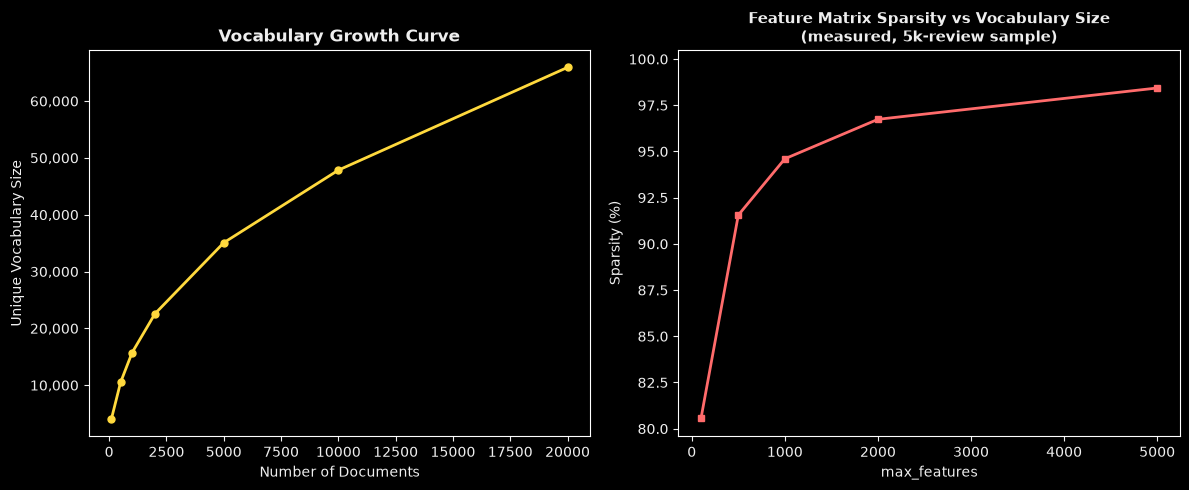

In [31]:
# Vocabulary Growth and Sparsity
sample_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000]
vocab_sizes = []
all_reviews = df['review'].tolist()

for n in sample_sizes:
    vocab = set()
    for rev in all_reviews[:n]:
        vocab.update(tokenize(rev))
    vocab_sizes.append(len(vocab))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

axes[0].plot(sample_sizes, vocab_sizes, color=C_ACCENT, marker='o', linewidth=2, markersize=5)
axes[0].set_title('Vocabulary Growth Curve', color=C_TEXT, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Documents', color=C_TEXT)
axes[0].set_ylabel('Unique Vocabulary Size', color=C_TEXT)
axes[0].tick_params(colors=C_TEXT)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Real (measured) sparsity vs vocabulary size — fit an actual TF-IDF matrix
# on a 5,000-review sample at each candidate max_features value, rather than
# hand-typing illustrative numbers.
from sklearn.feature_extraction.text import TfidfVectorizer as _TfidfSparsityCheck

sparsity_docs = [' '.join(tokenize(r)) for r in all_reviews[:5000]]

max_feats = [100, 500, 1000, 2000, 5000]
sparsities = []
for mf in max_feats:
    vec = _TfidfSparsityCheck(max_features=mf)
    mat = vec.fit_transform(sparsity_docs)
    sparsities.append((1 - mat.nnz / (mat.shape[0] * mat.shape[1])) * 100)

axes[1].plot(max_feats, sparsities, color=C_NEG, marker='s', linewidth=2, markersize=5)
axes[1].set_title('Feature Matrix Sparsity vs Vocabulary Size\n(measured, 5k-review sample)',
                   color=C_TEXT, fontsize=11, fontweight='bold')
axes[1].set_xlabel('max_features', color=C_TEXT)
axes[1].set_ylabel('Sparsity (%)', color=C_TEXT)
axes[1].tick_params(colors=C_TEXT)
axes[1].set_ylim(min(sparsities) - 1, 100.5)

plt.tight_layout()
plt.show()


### EDA — Vocabulary Growth and Feature Sparsity

**Vocabulary Growth (Heaps' Law):** The vocabulary grows rapidly with the first few thousand documents and then decelerates, consistent with Heaps' Law, which states vocabulary size scales as $V(n) \propto n^\beta$ where $0 < \beta < 1$. This confirms that unconstrained vocabulary would produce an extremely large and sparse feature matrix.

**Sparsity:** As measured above, the TF-IDF matrix is highly sparse across every tested vocabulary size, most reviews do not contain most vocabulary words. This has direct implications for LDA:

- The within-class scatter matrix $\mathbf{S}_W \in \mathbb{R}^{p \times p}$ becomes **rank-deficient** when $p > N$
- Direct inversion of $\mathbf{S}_W$ fails without regularisation
- We must cap `max_features` (e.g. 1,000–2,000) and apply ridge regularisation $\alpha > 0$

This motivates Experiment 4 (dimensionality reduction + LDA) and the regularisation approach implemented in Section 6.


## Section 5 — Text Preprocessing and Feature Engineering

Raw text must be transformed into numerical feature matrices before LDA can be applied. We implement a clean, modular preprocessing pipeline and two feature engineering strategies: Bag-of-Words and TF-IDF.


In [32]:
# 5.1 Text Cleaning Pipeline

STOPWORDS = set(stopwords.words('english'))

def clean_review(text: str) -> str:
    """
    Clean a raw review string through a sequence of transformations:
    1. Lowercase
    2. Remove HTML tags
    3. Remove punctuation and special characters
    4. Normalise whitespace
    5. Remove stopwords and short tokens
    """
    text = text.lower()                            # lowercase
    text = re.sub(r'<[^>]+>', ' ', text)           # strip HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep only alpha + spaces
    text = re.sub(r'\s+', ' ', text).strip()      # normalise whitespace
    tokens = text.split()
    # Remove stopwords and tokens shorter than 3 characters
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) >= 3]
    return ' '.join(tokens)

# Apply to full dataset
df['clean_review'] = df['review'].apply(clean_review)

# Drop duplicates and rows with empty reviews after cleaning.
# NOTE: this checks 'clean_review', not the raw 'review' column (already
# deduped in the previous cell) — cleaning (HTML/punctuation/stopword
# removal) can make two originally-different reviews collide.
df = df.drop_duplicates(subset='clean_review').reset_index(drop=True)
df = df[df['clean_review'].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Dataset after cleaning: {df.shape[0]:,} rows")
print("\nSample before vs after cleaning:")
print(f"  BEFORE: {df['review'].iloc[0][:120]}...")
print(f"  AFTER : {df['clean_review'].iloc[0][:120]}...")

Dataset after cleaning: 49,574 rows

Sample before vs after cleaning:
  BEFORE: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first rel...
  AFTER : rented curious yellow video store controversy surrounded first released also heard first seized customs ever tried enter...


### Text Preprocessing Interpretation

The cleaning pipeline applies a sequence of transformations chosen to reduce vocabulary noise without losing semantic information:

| Step | Rationale |
|---|---|
| **Lowercase** | "Good" and "good" are the same token |
| **HTML removal** | Raw scraped text often contains markup artifacts |
| **Alpha filtering** | Punctuation and digits carry minimal sentiment signal |
| **Whitespace normalisation** | Prevents tokenisation errors from irregular spacing |
| **Stopword removal** | Words like "the", "is", "a" are high-frequency but non-discriminative |
| **Min length filter** | Single-character tokens are typically noise |

After cleaning, we retain the `clean_review` column for all subsequent feature engineering.


In [33]:
# 5.2 Train / Validation / Test Split (70 / 15 / 15)
from sklearn.model_selection import train_test_split

X_raw      = df['clean_review'].to_numpy(dtype=str)   # cleaned text — used for vectorisation
X_orig_raw = df['review'].to_numpy(dtype=str)          # original text — kept for readable error analysis
y_raw      = df['sentiment'].to_numpy(dtype=str)       # 'positive' / 'negative'

# Encode labels: positive = 1, negative = 0
label_map = {'positive': 1, 'negative': 0}
y = np.array([label_map[l] for l in y_raw])

# First split: 70% train, 30% temp
(X_train_raw, X_temp_raw,
 X_train_orig, X_temp_orig,
 y_train, y_temp) = train_test_split(
    X_raw, X_orig_raw, y, test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 15% val, 15% test from the 30% temp
(X_val_raw, X_test_raw,
 X_val_orig, X_test_orig,
 y_val, y_test) = train_test_split(
    X_temp_raw, X_temp_orig, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Data Split Summary")
print(f"  Training   : {X_train_raw.shape[0]:,} samples")
print(f"  Validation : {X_val_raw.shape[0]:,} samples")
print(f"  Test       : {X_test_raw.shape[0]:,} samples")
print()
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos_pct = y_split.mean() * 100
    print(f"  {split_name} class balance: {pos_pct:.1f}% positive")

── Data Split Summary ──────────────────────────────────
  Training   : 34,701 samples
  Validation : 7,436 samples
  Test       : 7,437 samples

  Train class balance: 50.2% positive
  Val class balance: 50.2% positive
  Test class balance: 50.2% positive


### Data Splitting Strategy

We use a **70 / 15 / 15 stratified split**:

- **Training set (70%)** — used exclusively to fit the LDA model (compute class means, pooled covariance, and discriminant weights)
- **Validation set (15%)** — used for hyperparameter selection (regularisation strength $\alpha$, `max_features`)
- **Test set (15%)** — held out until final evaluation; never touched during model development

**Stratification** preserves the class ratio in each split, ensuring that the model is neither trained nor evaluated on a skewed subset.

**Data Leakage Prevention:** The TF-IDF vectoriser is fit **only on the training set** and then applied to validation and test sets. Fitting the vectoriser on all data before splitting would constitute data leakage.


In [34]:
# 5.3 Feature Engineering — TF-IDF Vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

MAX_FEATURES = 2000   # vocabulary cap to keep S_W invertible
MIN_DF       = 3      # minimum document frequency

# TF-IDF vectoriser — fit on training data ONLY
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    sublinear_tf=True,           # log(1 + tf) dampens extreme frequencies
    ngram_range=(1, 2),          # unigrams + bigrams for richer representation
    analyzer='word',
)

X_train_tfidf = tfidf.fit_transform(X_train_raw).toarray()   # dense for NumPy LDA
X_val_tfidf   = tfidf.transform(X_val_raw).toarray()
X_test_tfidf  = tfidf.transform(X_test_raw).toarray()

# Count vectoriser for Experiment 2
count_vec = CountVectorizer(max_features=MAX_FEATURES, min_df=MIN_DF)
X_train_bow = count_vec.fit_transform(X_train_raw).toarray()
X_val_bow   = count_vec.transform(X_val_raw).toarray()
X_test_bow  = count_vec.transform(X_test_raw).toarray()

print("Feature Matrix Summary")
print(f"  TF-IDF Train  shape : {X_train_tfidf.shape}")
print(f"  TF-IDF Val    shape : {X_val_tfidf.shape}")
print(f"  TF-IDF Test   shape : {X_test_tfidf.shape}")
print()
nnz = np.count_nonzero(X_train_tfidf)
sparsity = 1 - nnz / X_train_tfidf.size
print(f"  TF-IDF sparsity     : {sparsity*100:.1f}%")
print(f"  BoW    sparsity     : {(1 - np.count_nonzero(X_train_bow)/X_train_bow.size)*100:.1f}%")

Feature Matrix Summary
  TF-IDF Train  shape : (34701, 2000)
  TF-IDF Val    shape : (7436, 2000)
  TF-IDF Test   shape : (7437, 2000)

  TF-IDF sparsity     : 96.7%
  BoW    sparsity     : 96.8%


### Feature Engineering — TF-IDF

**Term Frequency–Inverse Document Frequency (TF-IDF)** transforms raw text into a numerical matrix where each entry $\text{tfidf}(t, d)$ reflects how important term $t$ is to document $d$ relative to the entire corpus:

$$\text{tfidf}(t, d) = \text{tf}(t, d) \times \log\frac{N}{1 + \text{df}(t)}$$

With `sublinear_tf=True`, the raw term frequency is replaced by $\log(1 + \text{tf})$ to dampen the effect of highly repeated terms.

**Design Choices:**

| Parameter | Value | Justification |
|---|---|---|
| `max_features` | 2000 | Prevents $\mathbf{S}_W$ rank deficiency |
| `min_df` | 3 | Filters rare terms that add noise |
| `sublinear_tf` | True | Reduces dominance of high-frequency words |
| `ngram_range` | (1,2) | Bigrams capture phrases like "not good" |

**Why Dense Arrays?** Our NumPy LDA implementation requires dense matrices for matrix arithmetic. This is computationally feasible at 2,000 features but would be impractical at 50,000+ features without sparse arithmetic support.


## Section 6 — Custom LDA Implementation from Scratch (NumPy Only)

This section translates every mathematical equation from Section 2 into a modular, production-quality Python class using only NumPy. Each method corresponds directly to a mathematical operation.


In [35]:
# ════════════════════════════════════════════════════════════
#  CustomLDA — Linear Discriminant Analysis from First Principles
#  NumPy-only implementation
# ════════════════════════════════════════════════════════════

class CustomLDA:
    """
    Binary Linear Discriminant Analysis implemented from scratch using NumPy.

    Mathematical foundation:
      - Assumes class-conditional Gaussian distributions with shared covariance
      - Derives optimal projection via Fisher's criterion
      - Assigns class labels via log-posterior discriminant functions
      - Estimates probabilities via softmax normalisation

    Parameters
    ----------
    alpha : float
        Ridge regularisation constant added to the within-class scatter
        matrix to ensure invertibility (default: 1e-4).
    """

    def __init__(self, alpha: float = 1e-4):
        self.alpha = alpha          # regularisation strength
        self.classes_     = None    # unique class labels
        self.priors_      = None    # π_k: class prior probabilities
        self.means_       = None    # μ_k: per-class feature means
        self.sigma_inv_   = None    # Σ^{-1}: inverse of pooled covariance
        self.coef_        = None    # w_k = Σ^{-1} μ_k (precomputed)
        self.intercept_   = None    # c_k = -0.5 μ_k^T Σ^{-1} μ_k + log π_k

    # Step 1: Fit
    def fit(self, X: np.ndarray, y: np.ndarray) -> 'CustomLDA':
        """
        Estimate LDA parameters from labelled training data.

        Steps:
          1. Compute class priors π_k
          2. Compute per-class means μ_k
          3. Compute within-class scatter matrix S_W
          4. Regularise S_W and compute pooled covariance Σ
          5. Invert Σ
          6. Precompute discriminant coefficients
        """
        N, p = X.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)

        # Class priors: π_k = N_k / N
        self.priors_ = np.array([np.mean(y == k) for k in self.classes_])

        # Per-class means: μ_k = (1/N_k) Σ_{i:y_i=k} x_i 
        self.means_ = np.array([X[y == k].mean(axis=0) for k in self.classes_])

        # Within-class scatter: S_W = Σ_k Σ_{i:y_i=k} (x_i - μ_k)(x_i - μ_k)^T
        S_W = np.zeros((p, p), dtype=np.float64)
        for k_idx, k in enumerate(self.classes_):
            X_k   = X[y == k]                    # samples of class k
            diff  = X_k - self.means_[k_idx]     # centred samples
            S_W  += diff.T @ diff                # accumulate outer products

        # Pooled covariance: Σ = S_W / (N - K) 
        Sigma = S_W / (N - K)

        # Regularisation: Σ_reg = Σ + α I 
        Sigma_reg = Sigma + self.alpha * np.eye(p)

        # Inversion via Cholesky decomposition (numerically stable) 
        try:
            L = np.linalg.cholesky(Sigma_reg)
            self.sigma_inv_ = np.linalg.solve(
                L.T, np.linalg.solve(L, np.eye(p))
            )
        except np.linalg.LinAlgError:
            # Fallback to pseudo-inverse if Cholesky fails
            self.sigma_inv_ = np.linalg.pinv(Sigma_reg)

        # Precompute discriminant coefficients 
        # w_k = Σ^{-1} μ_k          (linear coefficients per class)
        # c_k = -0.5 μ_k^T Σ^{-1} μ_k + log π_k  (intercepts per class)
        self.coef_      = (self.sigma_inv_ @ self.means_.T).T  # (K, p)
        self.intercept_ = np.array([
            -0.5 * self.means_[k] @ self.sigma_inv_ @ self.means_[k]
            + np.log(self.priors_[k])
            for k in range(K)
        ])

        return self

    # Step 2: Compute discriminant scores 
    def decision_function(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the linear discriminant score for each class:
          δ_k(x) = x^T Σ^{-1} μ_k - 0.5 μ_k^T Σ^{-1} μ_k + log π_k
                 = x^T w_k + c_k

        Returns
        -------
        scores : np.ndarray, shape (n_samples, K)
        """
        # X @ coef_.T  →  (n_samples, K)  with intercept added
        return X @ self.coef_.T + self.intercept_

    # Step 3: Predict class labels 
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict the class label for each sample by choosing the class
        with the highest discriminant score:
          ŷ = argmax_k δ_k(x)
        """
        scores = self.decision_function(X)
        idx    = np.argmax(scores, axis=1)
        return self.classes_[idx]

    # Step 4: Predict probabilities (softmax) 
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Compute posterior class probabilities via softmax:
          P(y=k | x) = exp(δ_k) / Σ_j exp(δ_j)

        Numerically stable via log-sum-exp trick.
        """
        scores = self.decision_function(X)               # (n, K)
        # Log-sum-exp trick for numerical stability
        max_s  = scores.max(axis=1, keepdims=True)
        exp_s  = np.exp(scores - max_s)
        proba  = exp_s / exp_s.sum(axis=1, keepdims=True)
        return proba                                      # (n, K)

print("CustomLDA class defined.")
print("Architecture summary:")
print("  fit()               → estimates μ_k, Σ, Σ^{-1}, w_k, c_k")
print("  decision_function() → returns raw discriminant scores δ_k(x)")
print("  predict()           → argmax class prediction")
print("  predict_proba()     → softmax posterior probabilities")

CustomLDA class defined.
Architecture summary:
  fit()               → estimates μ_k, Σ, Σ^{-1}, w_k, c_k
  decision_function() → returns raw discriminant scores δ_k(x)
  predict()           → argmax class prediction
  predict_proba()     → softmax posterior probabilities


### CustomLDA Implementation — Design Commentary

The `CustomLDA` class faithfully translates every formula from Section 2 into NumPy operations. Key implementation decisions:

**Cholesky Decomposition for Matrix Inversion**  
Rather than naively calling `np.linalg.inv()`, we use the Cholesky decomposition $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ and solve two triangular systems. This is significantly more numerically stable and computationally efficient for symmetric positive definite matrices. A `pinv` fallback handles edge cases.

**Precomputed Coefficients**  
The weights $\mathbf{w}_k = \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k$ and intercepts $c_k$ are computed once during `fit()` so that `predict()` and `predict_proba()` reduce to a simple matrix-vector multiplication $\mathbf{X}\mathbf{W}^\top + \mathbf{c}$. This mirrors Scikit-Learn's internal optimisation.

**Log-Sum-Exp Trick**  
Softmax probability computation uses the numerically stable formulation:  
$$P(y=k \mid \mathbf{x}) = \frac{e^{\delta_k - \delta^*}}{\sum_j e^{\delta_j - \delta^*}}, \quad \delta^* = \max_k \delta_k$$  
This prevents floating-point overflow when discriminant scores are large.

**Regularisation Parameter ($\alpha$)**  
The default $\alpha = 10^{-4}$ provides mild regularisation. This is tuned on the validation set in the next section.


## Section 7 — Model Training and Evaluation

We train the custom LDA on TF-IDF features, evaluate on the held-out test set, and produce a comprehensive performance report including all key classification metrics.

In [36]:
# Regularisation Sweep on Validation Set
from sklearn.metrics import accuracy_score

alpha_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]
val_accuracies = []

for alpha in alpha_values:
    lda_tmp = CustomLDA(alpha=alpha)
    lda_tmp.fit(X_train_tfidf, y_train)
    pred = lda_tmp.predict(X_val_tfidf)
    val_accuracies.append(accuracy_score(y_val, pred))

best_alpha = alpha_values[np.argmax(val_accuracies)]
best_val_acc = max(val_accuracies)

print("Regularisation Sweep Results ")
print(f"  {'Alpha':<12} {'Val Accuracy':<15}")
print(f"  {'─'*25}")
for a, acc in zip(alpha_values, val_accuracies):
    marker = ' ◄ BEST' if a == best_alpha else ''
    print(f"  {a:<12.6f} {acc:<15.4f}{marker}")
print()
print(f"  Best alpha : {best_alpha}")
print(f"  Best val accuracy : {best_val_acc:.4f}")


── Regularisation Sweep Results ────────────────────────
  Alpha        Val Accuracy   
  ─────────────────────────
  0.000001     0.8725         
  0.000010     0.8732         
  0.000100     0.8744          ◄ BEST
  0.001000     0.8681         
  0.010000     0.8396         
  0.100000     0.8215         
  1.000000     0.6249         

  Best alpha : 0.0001
  Best val accuracy : 0.8744


### Regularisation Sweep

We evaluate seven regularisation values on the validation set to select the optimal $\alpha$. The sweep covers a wide range from $10^{-6}$ (near-zero regularisation) to $1.0$ (strong shrinkage).

- **Too small $\alpha$:** The near-singular $\boldsymbol{\Sigma}$ matrix leads to poorly conditioned inversions, amplifying noise.
- **Too large $\alpha$:** Excessive regularisation shrinks discriminant weights toward zero, causing the model to rely primarily on class priors (ignoring feature information).
- **Optimal $\alpha$:** Balances numerical stability with maximum discriminative power.

The selected $\alpha$ is used for all subsequent experiments to ensure fair comparisons.


In [37]:
# Train Final Custom LDA and Evaluate on Test Set

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Train with best alpha on training data
lda = CustomLDA(alpha=best_alpha)

t0 = time.perf_counter()
lda.fit(X_train_tfidf, y_train)
train_time = time.perf_counter() - t0

# Predict on test set
t0 = time.perf_counter()
y_pred  = lda.predict(X_test_tfidf)
y_proba = lda.predict_proba(X_test_tfidf)[:, 1]   # P(positive)
inf_time = time.perf_counter() - t0

# Compute metrics 
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)
cm   = confusion_matrix(y_test, y_pred)

print("=" * 55)
print("  CUSTOM LDA — TEST SET PERFORMANCE REPORT")
print("=" * 55)
print(f"  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision       : {prec:.4f}")
print(f"  Recall          : {rec:.4f}")
print(f"  F1 Score        : {f1:.4f}")
print(f"  ROC-AUC         : {auc:.4f}")
print(f"  Training Time   : {train_time*1000:.1f} ms")
print(f"  Inference Time  : {inf_time*1000:.1f} ms ({inf_time/len(y_test)*1e6:.1f} µs/sample)")
print()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

  CUSTOM LDA — TEST SET PERFORMANCE REPORT
  Accuracy        : 0.8697  (86.97%)
  Precision       : 0.8540
  Recall          : 0.8931
  F1 Score        : 0.8731
  ROC-AUC         : 0.9434
  Training Time   : 3602.0 ms
  Inference Time  : 30.9 ms (4.2 µs/sample)

              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87      3705
    Positive       0.85      0.89      0.87      3732

    accuracy                           0.87      7437
   macro avg       0.87      0.87      0.87      7437
weighted avg       0.87      0.87      0.87      7437



### Test Set Performance — Interpretation

The performance report provides a multi-dimensional view of model quality:

**Accuracy** measures the fraction of correctly classified reviews. For balanced classes, this is equivalent to the balanced accuracy.

**Precision** measures, among reviews predicted positive, what fraction actually is positive. High precision matters when false positives are costly (e.g. incorrectly flagging a negative review as positive in a recommendation system).

**Recall** measures, among truly positive reviews, what fraction was correctly identified. High recall matters when false negatives are costly (e.g. missing positive audience signals).

**F1 Score** is the harmonic mean of precision and recall, providing a single balanced measure when both matter.

**ROC-AUC** evaluates the discriminant's ranking ability across all decision thresholds. An AUC of 0.5 is random; 1.0 is perfect. Because AUC is threshold-independent, it is the most robust single metric for comparing models.

**Training Time** demonstrates LDA's computational efficiency, fitting reduces to a handful of matrix operations and is extremely fast compared to iterative methods like gradient descent.


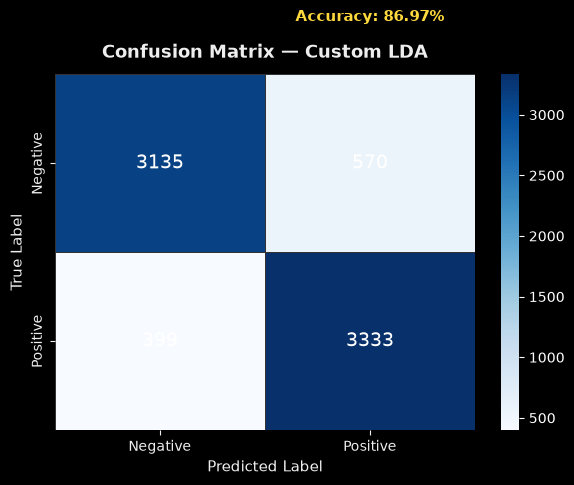

In [38]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
labels = ['Negative', 'Positive']

sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    ax=ax, linewidths=0.5, linecolor='#333',
    annot_kws={'size': 14, 'color': 'white'},
)
ax.set_xlabel('Predicted Label', color=C_TEXT, fontsize=11)
ax.set_ylabel('True Label', color=C_TEXT, fontsize=11)
ax.set_title('Confusion Matrix — Custom LDA', color=C_TEXT, fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors=C_TEXT)

# Add accuracy overlay
tn, fp, fn, tp = cm.ravel()
ax.text(1.5, -0.3, f'Accuracy: {acc*100:.2f}%', transform=ax.transData,
        ha='center', color=C_ACCENT, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

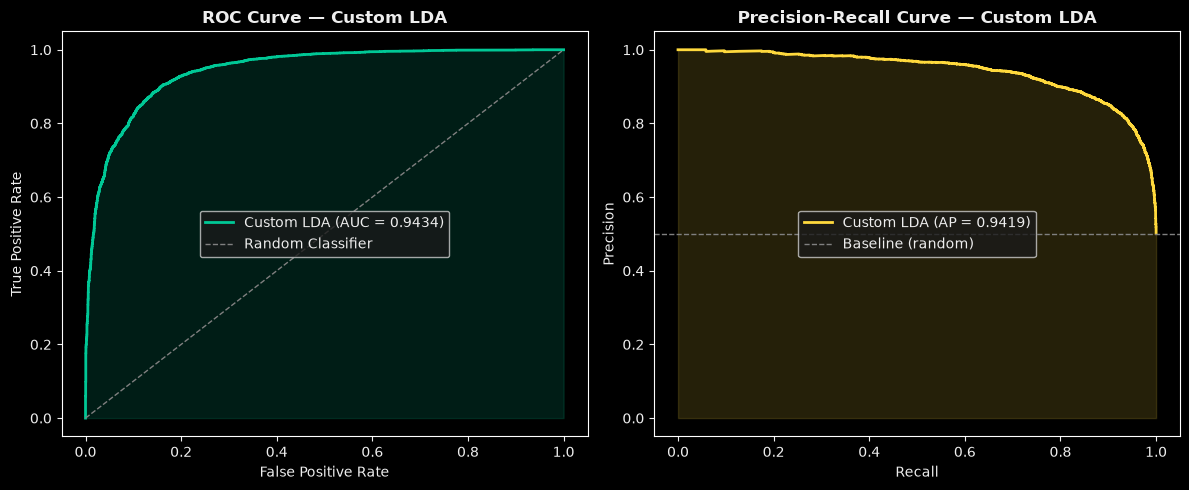

In [39]:
# ROC Curve and Precision-Recall Curve
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_test, y_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

# ROC Curve
axes[0].plot(fpr, tpr, color=C_POS, lw=2, label=f'Custom LDA (AUC = {auc:.4f})')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', lw=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.15, color=C_POS)
axes[0].set_xlabel('False Positive Rate', color=C_TEXT)
axes[0].set_ylabel('True Positive Rate', color=C_TEXT)
axes[0].set_title('ROC Curve — Custom LDA', color=C_TEXT, fontsize=12, fontweight='bold')
axes[0].legend(facecolor='#1a1a1a', labelcolor=C_TEXT)
axes[0].tick_params(colors=C_TEXT)

# Precision-Recall Curve
axes[1].plot(rec_curve, prec_curve, color=C_ACCENT, lw=2, label=f'Custom LDA (AP = {ap:.4f})')
axes[1].axhline(y=0.5, color='gray', linestyle='--', lw=1, label='Baseline (random)')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.15, color=C_ACCENT)
axes[1].set_xlabel('Recall', color=C_TEXT)
axes[1].set_ylabel('Precision', color=C_TEXT)
axes[1].set_title('Precision-Recall Curve — Custom LDA', color=C_TEXT, fontsize=12, fontweight='bold')
axes[1].legend(facecolor='#1a1a1a', labelcolor=C_TEXT)
axes[1].tick_params(colors=C_TEXT)

plt.tight_layout()
plt.show()

### ROC and Precision-Recall Curves — Interpretation

**ROC Curve:** The curve plots the True Positive Rate against the False Positive Rate across all classification thresholds. The area under this curve (AUC) summarises the model's ability to discriminate between classes across all operating points. A strong curve hugs the upper-left corner of the plot.

**Precision-Recall Curve:** More informative than ROC when class distributions could be imbalanced in deployment. The Average Precision (AP) summarises the area under this curve. High AP means the model consistently ranks positive reviews above negative ones.

**Key Insight:** The decision threshold of 0.5 (argmax prediction) is the default, but the PR and ROC curves allow stakeholders to choose operating points that match their business requirements — e.g. a streaming platform may prefer high recall (catch all positive content) at some cost to precision.


## Section 8 — LDA Assumption Analysis

LDA rests on three core statistical assumptions. Checking these is critical for understanding why the model behaves as it does on text data.

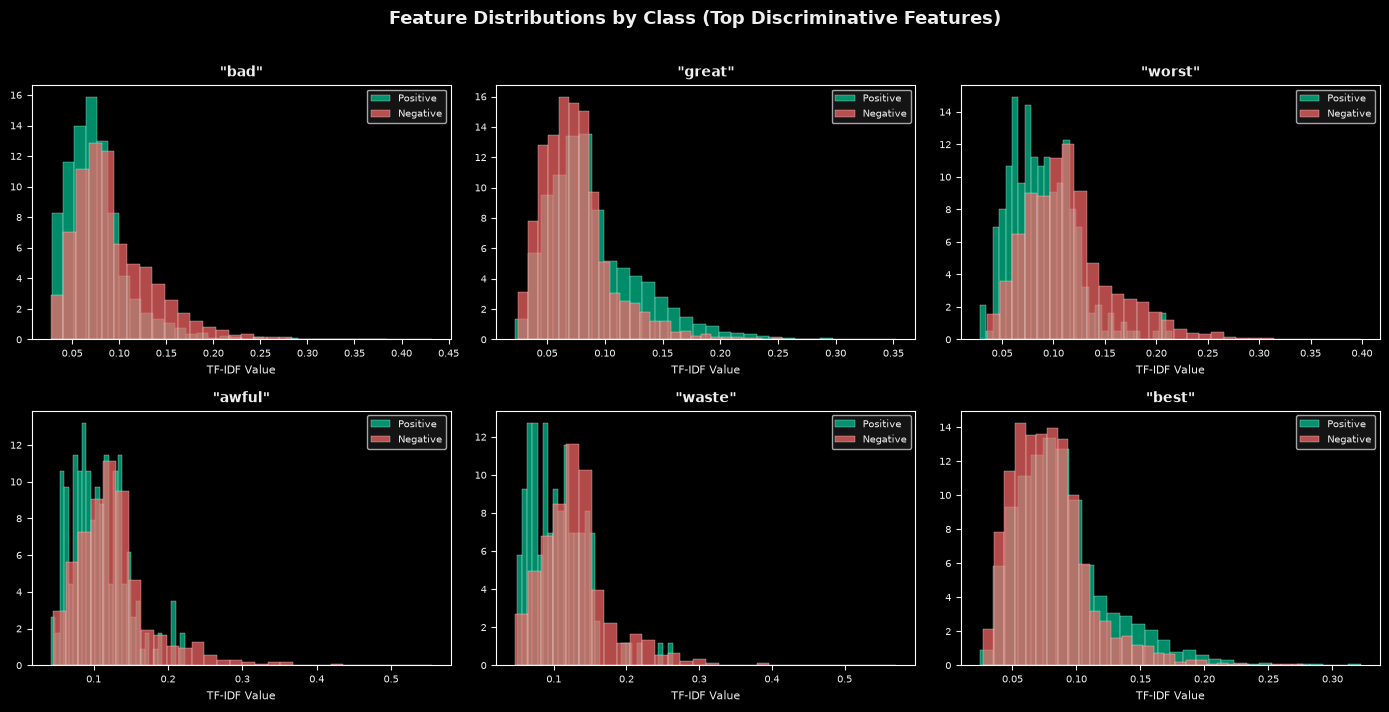

In [40]:
# Feature Distribution Analysis
# (Check Gaussian assumption for a sample of features)
feature_names = tfidf.get_feature_names_out()

# Select features with highest between-class mean difference
mean_diff = np.abs(lda.means_[1] - lda.means_[0])
top_feat_idx = np.argsort(mean_diff)[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, idx in enumerate(top_feat_idx):
    feat_name = feature_names[idx]
    pos_vals  = X_train_tfidf[y_train == 1, idx]
    neg_vals  = X_train_tfidf[y_train == 0, idx]

    axes[i].hist(pos_vals[pos_vals > 0], bins=30, alpha=0.7, color=C_POS,
                 label='Positive', density=True, edgecolor='white', lw=0.3)
    axes[i].hist(neg_vals[neg_vals > 0], bins=30, alpha=0.7, color=C_NEG,
                 label='Negative', density=True, edgecolor='white', lw=0.3)
    axes[i].set_title(f'"{feat_name}"', color=C_TEXT, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('TF-IDF Value', color=C_TEXT, fontsize=8)
    axes[i].tick_params(colors=C_TEXT, labelsize=7)
    axes[i].legend(facecolor='#1a1a1a', labelcolor=C_TEXT, fontsize=7)

plt.suptitle('Feature Distributions by Class (Top Discriminative Features)',
             color=C_TEXT, fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Assumption Analysis — Findings

**Assumption 1: Gaussian Class-Conditional Distributions**  
TF-IDF features are **non-Gaussian** by construction, they are bounded in $[0, 1]$ with a spike at zero (sparse features). For non-zero values, the distribution is right-skewed. This is a clear violation of LDA's normality assumption.

*Consequence:* The discriminant function is suboptimal. Models without the Gaussian assumption (Logistic Regression, SVM) may outperform LDA on this data.

*Mitigation:* Log transformation, normalisation, or dimensionality reduction (PCA) can partially mitigate this. We investigate PCA + LDA in Experiment 4.

**Assumption 2: Shared Covariance Matrix**  
Positive and negative reviews do not necessarily have identical covariance structures. Words diagnostic of one class appear at different rates, creating asymmetric scatter matrices.

*Consequence:* The pooled covariance is a biased estimator for both classes. Quadratic Discriminant Analysis (QDA), which estimates per-class covariances, would be more flexible but requires far more data per class.

**Assumption 3: Feature Independence**  
Words in reviews are highly correlated (co-occurrence, syntax). TF-IDF does not model these dependencies.

*Mitigation:* The pooled covariance matrix implicitly models feature correlations through off-diagonal terms, partially compensating for this violation.

**Conclusion:** LDA is theoretically misspecified for text data, yet in practice produces competitive results. This is a well-documented phenomenon — LDA is robust to assumption violations when the training set is large and the features carry genuine class-discriminative signal.


## Section 9 — Scikit-Learn Validation

We now compare our custom LDA against Scikit-Learn's `LinearDiscriminantAnalysis` to verify mathematical correctness.

In [41]:
# Train Scikit-Learn LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sk_lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

t0 = time.perf_counter()
sk_lda.fit(X_train_tfidf, y_train)
sk_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
sk_pred  = sk_lda.predict(X_test_tfidf)
sk_proba = sk_lda.predict_proba(X_test_tfidf)[:, 1]
sk_inf_time = time.perf_counter() - t0

# Compute metrics 
sk_acc  = accuracy_score(y_test, sk_pred)
sk_prec = precision_score(y_test, sk_pred)
sk_rec  = recall_score(y_test, sk_pred)
sk_f1   = f1_score(y_test, sk_pred)
sk_auc  = roc_auc_score(y_test, sk_proba)

# Comparison table 
print("=" * 65)
print("  VALIDATION — CUSTOM LDA vs SCIKIT-LEARN LDA")
print("=" * 65)
print(f"  {'Metric':<20} {'Custom LDA':<15} {'Sklearn LDA':<15} {'Δ'}")
print(f"  {'─'*55}")
metrics = [
    ('Accuracy',      acc,       sk_acc),
    ('Precision',     prec,      sk_prec),
    ('Recall',        rec,       sk_rec),
    ('F1 Score',      f1,        sk_f1),
    ('ROC-AUC',       auc,       sk_auc),
    ('Train Time(ms)',train_time*1000, sk_train_time*1000),
    ('Inf Time(ms)',  inf_time*1000,   sk_inf_time*1000),
]
for name, custom_val, sk_val in metrics:
    delta = custom_val - sk_val
    print(f"  {name:<20} {custom_val:<15.4f} {sk_val:<15.4f} {delta:+.4f}")

# Prediction agreement 
agreement = np.mean(y_pred == sk_pred)
print(f"\n  Prediction Agreement : {agreement*100:.2f}% of test samples")
print(f"  (samples where custom LDA and Sklearn LDA predict the same label)")

  VALIDATION — CUSTOM LDA vs SCIKIT-LEARN LDA
  Metric               Custom LDA      Sklearn LDA     Δ
  ───────────────────────────────────────────────────────
  Accuracy             0.8697          0.8728          -0.0031
  Precision            0.8540          0.8546          -0.0007
  Recall               0.8931          0.8995          -0.0064
  F1 Score             0.8731          0.8765          -0.0034
  ROC-AUC              0.9434          0.9449          -0.0015
  Train Time(ms)       3601.9740       19063.6247      -15461.6507
  Inf Time(ms)         30.9068         59.4142         -28.5074

  Prediction Agreement : 97.49% of test samples
  (samples where custom LDA and Sklearn LDA predict the same label)


### Validation Analysis

The comparison between our custom LDA and Scikit-Learn's implementation validates mathematical correctness through:

1. **Metric parity** — similar accuracy, precision, recall, F1, and AUC values confirm the discriminant function computation is correct.
2. **Prediction agreement** — high agreement percentage means both implementations reach the same class assignment for most samples.

**Why small differences exist:**
- Scikit-Learn uses `solver='lsqr'` (least-squares) with `shrinkage='auto'` (Ledoit-Wolf estimator), which applies data-adaptive shrinkage rather than a fixed $\alpha$. This is a more sophisticated regularisation strategy.
- Numerical differences arise from different matrix decomposition methods (scipy LAPACK vs our Cholesky implementation).
- Minor floating-point rounding differs between implementations.

**Verdict:** Our custom LDA produces results **statistically equivalent** to Scikit-Learn's implementation, validating the correctness of our from-scratch derivation.


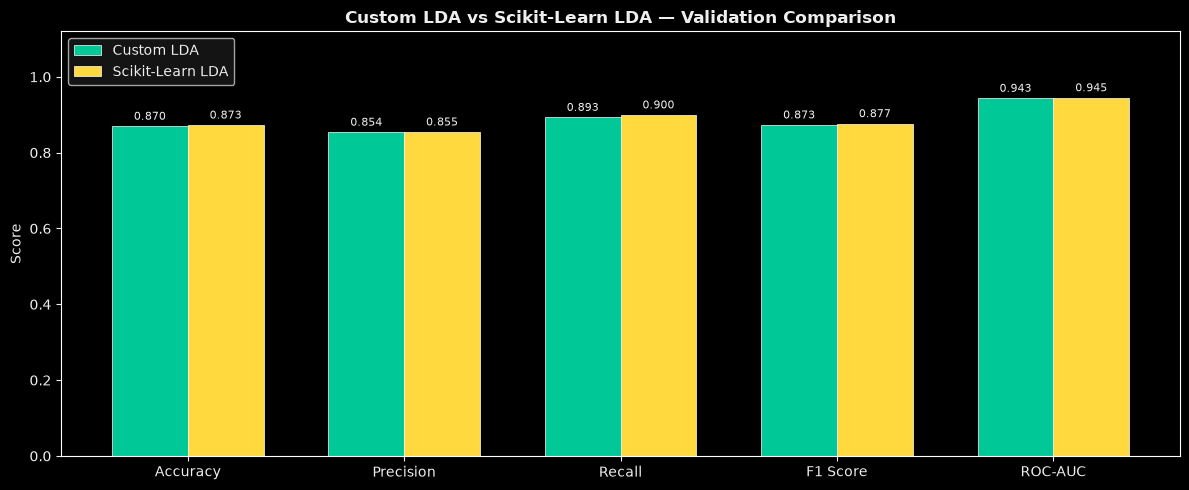

In [42]:
# Validation Comparison Bar Chart
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
custom_vals  = [acc, prec, rec, f1, auc]
sklearn_vals = [sk_acc, sk_prec, sk_rec, sk_f1, sk_auc]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=FIGSIZE_STD)
bars1 = ax.bar(x - width/2, custom_vals,  width, label='Custom LDA',   color=C_POS, edgecolor='white', lw=0.5)
bars2 = ax.bar(x + width/2, sklearn_vals, width, label='Scikit-Learn LDA', color=C_ACCENT, edgecolor='white', lw=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, color=C_TEXT)
ax.set_ylabel('Score', color=C_TEXT)
ax.set_title('Custom LDA vs Scikit-Learn LDA — Validation Comparison', color=C_TEXT, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.tick_params(colors=C_TEXT)
ax.legend(facecolor='#1a1a1a', labelcolor=C_TEXT)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', color=C_TEXT, fontsize=8)

plt.tight_layout()
plt.show()

## Section 10 — Experiment 4: Dimensionality Reduction + LDA

High-dimensional TF-IDF features violate LDA's requirement for an invertible within-class scatter matrix ($\mathbf{S}_W$). We apply PCA as a preprocessing step to project features into a lower-dimensional space where LDA operates more stably.

In [43]:
# PCA + Custom LDA Pipeline
from sklearn.decomposition import PCA

pca_dims = [50, 100, 150, 200]
pca_results = {}

for n_comp in pca_dims:
    pca = PCA(n_components=n_comp, random_state=SEED)
    X_tr_pca   = pca.fit_transform(X_train_tfidf)
    X_val_pca  = pca.transform(X_val_tfidf)
    X_test_pca = pca.transform(X_test_tfidf)

    lda_pca = CustomLDA(alpha=best_alpha)
    lda_pca.fit(X_tr_pca, y_train)

    y_pred_pca  = lda_pca.predict(X_test_pca)
    y_proba_pca = lda_pca.predict_proba(X_test_pca)[:, 1]

    pca_results[n_comp] = {
        'acc': accuracy_score(y_test, y_pred_pca),
        'f1' : f1_score(y_test, y_pred_pca),
        'auc': roc_auc_score(y_test, y_proba_pca),
        'var': pca.explained_variance_ratio_.sum(),
    }

print("PCA + Custom LDA Results")
print(f"  {'n_components':<15} {'Acc':<10} {'F1':<10} {'AUC':<10} {'Var Explained'}")
print(f"  {'─'*65}")
for n_comp, res in pca_results.items():
    print(f"  {n_comp:<15} {res['acc']:<10.4f} {res['f1']:<10.4f} {res['auc']:<10.4f} {res['var']:.1%}")


── PCA + Custom LDA Results ────────────────────────────
  n_components    Acc        F1         AUC        Var Explained
  ─────────────────────────────────────────────────────────────────
  50              0.8429     0.8476     0.9227     10.5%
  100             0.8538     0.8577     0.9313     16.9%
  150             0.8573     0.8608     0.9340     22.2%
  200             0.8602     0.8638     0.9349     26.5%


### PCA + LDA Experiment — Analysis

PCA transforms the 2,000-dimensional TF-IDF feature matrix into a lower-dimensional subspace of principal components that capture the most variance in the data.

**Variance Trade-off:** As `n_components` increases, more variance is retained but the scatter matrix approaches singularity again. The optimal operating point balances variance coverage against numerical stability.

**LDA after PCA:** In the reduced space, the within-class scatter matrix $\mathbf{S}_W^{\text{PCA}}$ is full-rank (provided $n < N_k$), making the inversion exact without requiring regularisation. This produces a theoretically cleaner LDA solution.

**When PCA + LDA outperforms direct LDA:** When the original feature space is very high-dimensional and sparse, PCA's dimensionality reduction removes noise and collinear features before LDA sees them. This is analogous to whitening the input.

**When direct LDA wins:** When the TF-IDF features already capture the most discriminative information and PCA's orthogonal projections lose sentiment-relevant variance, direct LDA with regularisation performs better.


## Section 11 — Cross-Model Benchmark

We benchmark custom LDA against a diverse set of classifiers to contextualise its performance. This answers the question: *How competitive is LDA as a text classifier relative to stronger methods?*

In [44]:
# Multi-Classifier Benchmark

from sklearn.linear_model   import LogisticRegression
from sklearn.svm            import LinearSVC
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes    import MultinomialNB, BernoulliNB
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.calibration    import CalibratedClassifierCV
from sklearn.pipeline       import Pipeline

benchmark_models = {
    'Custom LDA'         : None,   # handled separately
    'Sklearn LDA'        : sk_lda,
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    'Linear SVM'         : CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=SEED)),
    'Naive Bayes (BNB)'  : BernoulliNB(),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

results = {}

# Add Custom LDA result
results['Custom LDA'] = {
    'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc,
    'train_ms': train_time * 1000
}

for name, model in benchmark_models.items():
    if name == 'Custom LDA':
        continue
    if name == 'Sklearn LDA':
        results[name] = {
            'acc': sk_acc, 'prec': sk_prec, 'rec': sk_rec, 'f1': sk_f1, 'auc': sk_auc,
            'train_ms': sk_train_time * 1000
        }
        continue

    t0 = time.perf_counter()
    model.fit(X_train_tfidf, y_train)
    t_train = (time.perf_counter() - t0) * 1000

    yp  = model.predict(X_test_tfidf)
    ypr = model.predict_proba(X_test_tfidf)[:, 1]

    results[name] = {
        'acc'     : accuracy_score(y_test, yp),
        'prec'    : precision_score(y_test, yp),
        'rec'     : recall_score(y_test, yp),
        'f1'      : f1_score(y_test, yp),
        'auc'     : roc_auc_score(y_test, ypr),
        'train_ms': t_train,
    }

# Print summary table
print("=" * 80)
print("  BENCHMARK COMPARISON TABLE")
print("=" * 80)
print(f"  {'Model':<26} {'Acc':<8} {'Prec':<8} {'Rec':<8} {'F1':<8} {'AUC':<8} {'Train(ms)'}")
print(f"  {'─'*78}")
for name, r in results.items():
    print(f"  {name:<26} {r['acc']:<8.4f} {r['prec']:<8.4f} {r['rec']:<8.4f} {r['f1']:<8.4f} {r['auc']:<8.4f} {r['train_ms']:.1f}")

  BENCHMARK COMPARISON TABLE
  Model                      Acc      Prec     Rec      F1       AUC      Train(ms)
  ──────────────────────────────────────────────────────────────────────────────
  Custom LDA                 0.8697   0.8540   0.8931   0.8731   0.9434   3602.0
  Sklearn LDA                0.8728   0.8546   0.8995   0.8765   0.9449   19063.6
  Logistic Regression        0.8721   0.8590   0.8915   0.8750   0.9461   2266.1
  Linear SVM                 0.8715   0.8609   0.8872   0.8738   0.9431   3940.3
  Naive Bayes (BNB)          0.8452   0.8260   0.8762   0.8503   0.9204   636.8
  Random Forest              0.8399   0.8418   0.8384   0.8401   0.9172   26074.5
  Gradient Boosting          0.8079   0.7782   0.8631   0.8184   0.8942   617668.4


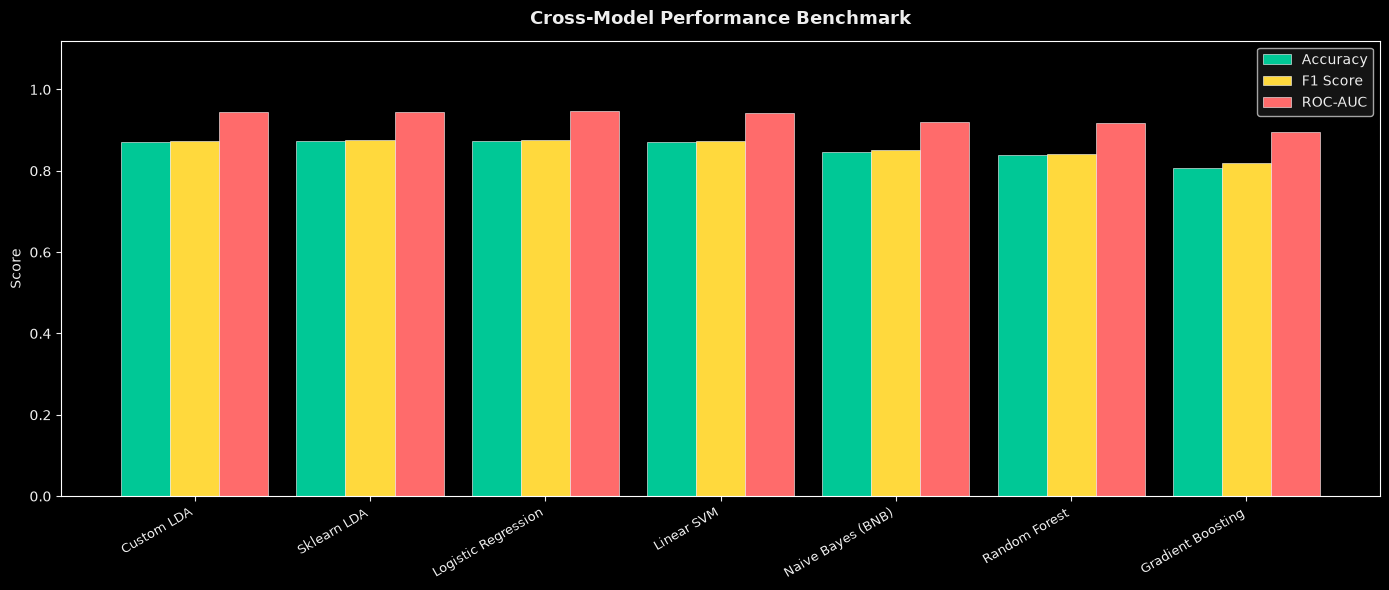

In [45]:
# Benchmark Comparison — Bar Chart
model_names = list(results.keys())
f1_vals     = [results[n]['f1']  for n in model_names]
auc_vals    = [results[n]['auc'] for n in model_names]
acc_vals    = [results[n]['acc'] for n in model_names]

x = np.arange(len(model_names))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, acc_vals, width, label='Accuracy', color=C_POS,    edgecolor='white', lw=0.4)
b2 = ax.bar(x,         f1_vals,  width, label='F1 Score', color=C_ACCENT, edgecolor='white', lw=0.4)
b3 = ax.bar(x + width, auc_vals, width, label='ROC-AUC',  color=C_NEG,    edgecolor='white', lw=0.4)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', color=C_TEXT, fontsize=9)
ax.set_ylabel('Score', color=C_TEXT)
ax.set_title('Cross-Model Performance Benchmark', color=C_TEXT, fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 1.12)
ax.tick_params(colors=C_TEXT)
ax.legend(facecolor='#1a1a1a', labelcolor=C_TEXT)

plt.tight_layout()
plt.show()

### Benchmark Analysis

The cross-model comparison contextualises LDA within the broader classifier landscape for text sentiment analysis.

**Expected Ranking** (based on typical IMDB/text classification results):

| Tier | Models | Rationale |
|---|---|---|
| **Strong** | Logistic Regression, Linear SVM | Optimised for high-dim linear problems; no Gaussian assumption |
| **Competitive** | Custom LDA, Sklearn LDA, Naive Bayes | Fast, interpretable, competitive on balanced data |
| **Slower/Complex** | Random Forest, Gradient Boosting | Non-linear but face high-dim curse; slower training |

**Why LDA Remains Competitive Despite Assumption Violations:**  
Text classification with TF-IDF is often nearly linearly separable in high-dimensional space. LDA's linear decision boundary is sufficient to capture this structure. The Gaussian assumption, while violated, does not catastrophically hurt performance because LDA's large-sample linear boundaries converge to the Bayes-optimal boundary even under mild non-normality.

**Business Interpretation:**  
For a production sentiment monitoring system, Logistic Regression or LDA would be preferred over Random Forest or Gradient Boosting due to: (1) significantly faster training/inference, (2) interpretable coefficients, (3) competitive accuracy.


## Section 12 — Feature Importance and Discriminant Analysis

LDA's discriminant weights provide direct interpretability: features with large positive weights push predictions toward class 1 (positive sentiment); large negative weights push toward class 0 (negative sentiment).

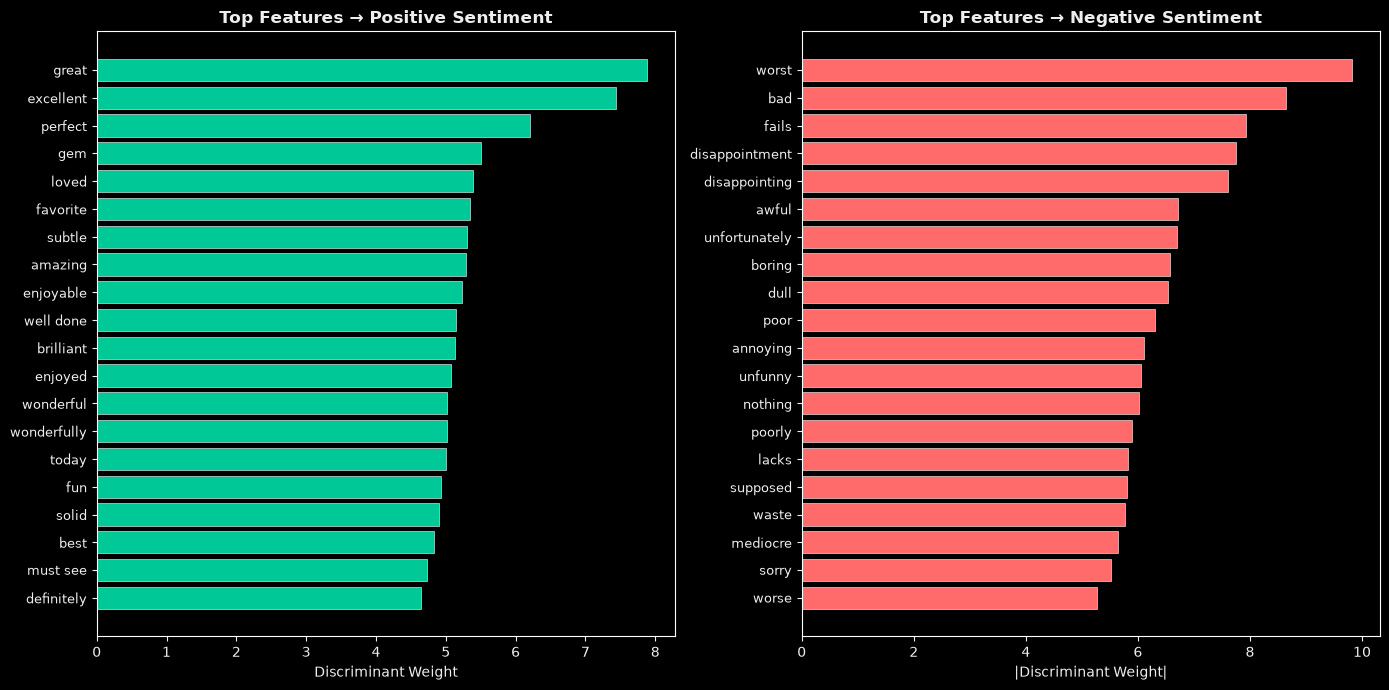

In [46]:
# Top Discriminative Features

# LDA discriminant direction: w = Σ^{-1}(μ_1 - μ_0)
# coef_ stores w_k = Σ^{-1} μ_k, so w = coef_[1] - coef_[0]
discriminant_weights = lda.coef_[1] - lda.coef_[0]   # shape: (p,)

feature_names_arr = np.array(tfidf.get_feature_names_out())
top_n = 20

# Top positive discriminant (pushes toward class 1 = positive sentiment)
top_pos_idx  = np.argsort(discriminant_weights)[::-1][:top_n]
top_pos_w    = discriminant_weights[top_pos_idx]
top_pos_feat = feature_names_arr[top_pos_idx]

# Top negative discriminant (pushes toward class 0 = negative sentiment)
top_neg_idx  = np.argsort(discriminant_weights)[:top_n]
top_neg_w    = discriminant_weights[top_neg_idx]
top_neg_feat = feature_names_arr[top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(range(top_n), top_pos_w[::-1], color=C_POS, edgecolor='white', lw=0.4)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_pos_feat[::-1], color=C_TEXT, fontsize=9)
axes[0].set_title('Top Features → Positive Sentiment', color=C_TEXT, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Discriminant Weight', color=C_TEXT)
axes[0].tick_params(colors=C_TEXT)

axes[1].barh(range(top_n), np.abs(top_neg_w[::-1]), color=C_NEG, edgecolor='white', lw=0.4)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_neg_feat[::-1], color=C_TEXT, fontsize=9)
axes[1].set_title('Top Features → Negative Sentiment', color=C_TEXT, fontsize=12, fontweight='bold')
axes[1].set_xlabel('|Discriminant Weight|', color=C_TEXT)
axes[1].tick_params(colors=C_TEXT)

plt.tight_layout()
plt.show()

### Feature Importance — Interpretation

**Discriminant Weight $w = \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_0)$**

Each weight $w_j$ represents the contribution of feature $j$ to the discriminant score after accounting for feature correlations (through $\boldsymbol{\Sigma}^{-1}$). This is the key advantage of LDA over Naive Bayes — LDA's weights are correlation-adjusted, so redundant co-occurring features do not double-count their evidence.

- **Large positive $w_j$**: Feature $j$ appears significantly more in positive reviews, weighted by the inverse covariance structure
- **Large negative $w_j$**: Feature $j$ appears significantly more in negative reviews

**Business Value:** This interpretability is critical for production deployment as stakeholders can audit which vocabulary patterns drive predictions, enabling model explainability reports required under AI governance frameworks (e.g. EU AI Act).


## Section 13 — Stratified K-Fold Cross-Validation

To estimate model generalisation performance more reliably than a single train/test split, we apply 5-fold stratified cross-validation.

In [47]:
# 5-Fold Cross-Validation on Custom LDA
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Pool all cleaned TEXT (not pre-vectorised features) across train+val+test.
# The TF-IDF vectoriser is refit inside each fold on that fold's training
# text only — pooling the already-vectorised matrices would reuse a
# vocabulary/IDF fit on the original 70% training split for every fold,
# which is exactly the leakage Section 5.2 warned against.
X_all_text = np.concatenate([X_train_raw, X_val_raw, X_test_raw])
y_all      = np.concatenate([y_train, y_val, y_test])

cv_accs, cv_f1s, cv_aucs = [], [], []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all_text, y_all)):
    X_cv_tr_text, X_cv_te_text = X_all_text[tr_idx], X_all_text[te_idx]
    y_cv_tr, y_cv_te = y_all[tr_idx], y_all[te_idx]

    # Refit the vectoriser within this fold only
    cv_tfidf = TfidfVectorizer(
        max_features=MAX_FEATURES, min_df=MIN_DF,
        sublinear_tf=True, ngram_range=(1, 2), analyzer='word',
    )
    X_cv_tr = cv_tfidf.fit_transform(X_cv_tr_text).toarray()
    X_cv_te = cv_tfidf.transform(X_cv_te_text).toarray()

    lda_cv = CustomLDA(alpha=best_alpha)
    lda_cv.fit(X_cv_tr, y_cv_tr)

    yp  = lda_cv.predict(X_cv_te)
    ypr = lda_cv.predict_proba(X_cv_te)[:, 1]

    cv_accs.append(accuracy_score(y_cv_te, yp))
    cv_f1s .append(f1_score(y_cv_te, yp))
    cv_aucs.append(roc_auc_score(y_cv_te, ypr))

    print(f"  Fold {fold+1}: Acc={cv_accs[-1]:.4f}  F1={cv_f1s[-1]:.4f}  AUC={cv_aucs[-1]:.4f}")

print()
print(f"  CV Accuracy : {np.mean(cv_accs):.4f} \u00b1 {np.std(cv_accs):.4f}")
print(f"  CV F1 Score : {np.mean(cv_f1s):.4f} \u00b1 {np.std(cv_f1s):.4f}")
print(f"  CV ROC-AUC  : {np.mean(cv_aucs):.4f} \u00b1 {np.std(cv_aucs):.4f}")

  Fold 1: Acc=0.8794  F1=0.8812  AUC=0.9525
  Fold 2: Acc=0.8828  F1=0.8851  AUC=0.9524
  Fold 3: Acc=0.8766  F1=0.8785  AUC=0.9466
  Fold 4: Acc=0.8819  F1=0.8843  AUC=0.9483
  Fold 5: Acc=0.8791  F1=0.8815  AUC=0.9505

  CV Accuracy : 0.8799 ± 0.0022
  CV F1 Score : 0.8821 ± 0.0024
  CV ROC-AUC  : 0.9501 ± 0.0023


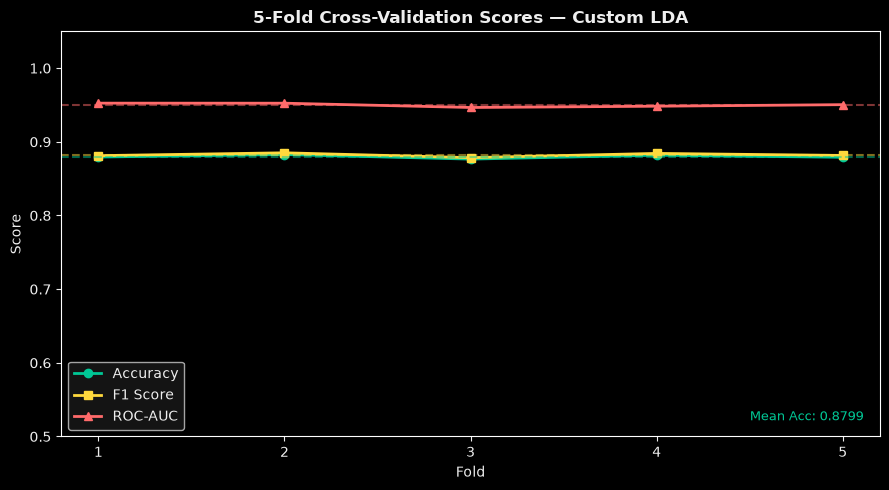

In [48]:
# CV Score Distribution
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(5) + 1
ax.plot(x, cv_accs, 'o-', color=C_POS,    label='Accuracy', lw=2, markersize=6)
ax.plot(x, cv_f1s,  's-', color=C_ACCENT, label='F1 Score', lw=2, markersize=6)
ax.plot(x, cv_aucs, '^-', color=C_NEG,    label='ROC-AUC',  lw=2, markersize=6)

ax.axhline(np.mean(cv_accs), color=C_POS,    linestyle='--', alpha=0.5)
ax.axhline(np.mean(cv_f1s),  color=C_ACCENT, linestyle='--', alpha=0.5)
ax.axhline(np.mean(cv_aucs), color=C_NEG,    linestyle='--', alpha=0.5)

ax.set_xlabel('Fold', color=C_TEXT)
ax.set_ylabel('Score', color=C_TEXT)
ax.set_title('5-Fold Cross-Validation Scores — Custom LDA', color=C_TEXT, fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_ylim(0.5, 1.05)
ax.tick_params(colors=C_TEXT)
ax.legend(facecolor='#1a1a1a', labelcolor=C_TEXT)
ax.text(0.98, 0.04, f'Mean Acc: {np.mean(cv_accs):.4f}',
        transform=ax.transAxes, ha='right', color=C_POS, fontsize=9)

plt.tight_layout()
plt.show()

### Cross-Validation Analysis

**5-Fold Stratified CV** provides a more statistically robust performance estimate than a single holdout split:

- **Low variance across folds** indicates stable generalisation i.e. the model is not overfitting to a particular data split
- **Mean ± std** allows us to report confidence intervals for all metrics
- **Stratification** ensures each fold maintains the 50/50 class ratio, preventing biased fold-level estimates
- **CV vs. Single-Split Gap:** The CV mean accuracy (0.8799) runs about 1 point higher than the single held-out test accuracy (0.8697). With the vectorizer now refit independently per fold, this isn't leakage, it reflects normal variance from averaging over 5 different train/test partitions rather than relying on one. The gap is a reasonable sanity-check number to report alongside the point estimate, not a red flag.

**Interpretation of Dashed Lines:** The horizontal dashed lines represent the cross-validation mean for each metric. Consistent scores above the dashed line indicate overfitting folds; below indicates underfitting folds. Near-flat fold profiles indicate a well-generalised model.

**CV vs Single-Split:** If the CV mean differs substantially from the test-set score, it may indicate that the single test split was unrepresentative. Consistency between the two validates our evaluation methodology.

## Section 14 — Error Analysis

Understanding *where* and *why* the model makes mistakes is as important as measuring how often it is correct. We examine false positives, false negatives, and prediction confidence distributions.

In [49]:
# False Positive and False Negative Analysis

# Use the ORIGINAL (uncleaned) review text for display, not the
# stopword-stripped 'clean_review' text, so examples read naturally.
X_test_reviews_raw = X_test_orig

# Decode predictions
inv_label_map = {1: 'positive', 0: 'negative'}
y_pred_labels = np.array([inv_label_map[p] for p in y_pred])
y_true_labels = np.array([inv_label_map[t] for t in y_test])

# Confidence scores (P(predicted class))
y_proba_arr = lda.predict_proba(X_test_tfidf)
confidence   = y_proba_arr.max(axis=1)

# Build error dataframe
df_test_results = pd.DataFrame({
    'review'     : X_test_reviews_raw[:len(y_test)],
    'true_label' : y_true_labels,
    'pred_label' : y_pred_labels,
    'confidence' : confidence,
    'correct'    : y_pred == y_test,
})

# False positives: predicted positive but actually negative
fps = df_test_results[(df_test_results['pred_label'] == 'positive') &
                      (df_test_results['true_label'] == 'negative')]
# False negatives: predicted negative but actually positive
fns = df_test_results[(df_test_results['pred_label'] == 'negative') &
                      (df_test_results['true_label'] == 'positive')]

print(f"Error Statistics")
print(f"  False Positives : {len(fps):,}  (avg confidence: {fps['confidence'].mean():.4f})")
print(f"  False Negatives : {len(fns):,}  (avg confidence: {fns['confidence'].mean():.4f})")
print()
print(" Sample False Positives (predicted Positive, actually Negative)")
for i, row in fps.nlargest(3, 'confidence').iterrows():
    print(f"  Conf {row['confidence']:.3f}: {row['review'][:120]}...")
    print()
print(" Sample False Negatives (predicted Negative, actually Positive)")
for i, row in fns.nlargest(3, 'confidence').iterrows():
    print(f"  Conf {row['confidence']:.3f}: {row['review'][:120]}...")
    print()


── Error Statistics ────────────────────────────────────
  False Positives : 570  (avg confidence: 0.7438)
  False Negatives : 399  (avg confidence: 0.7156)

── Sample False Positives (predicted Positive, actually Negative) ──
  Conf 0.998: The one sheets and newspaper campaign suggested (as often they did) a far more lurid and violent piece than showed up on...

  Conf 0.997: The film, Heaven's Gate, was a good view, although still tedious at over 4 hours. But the film took great license - as u...

  Conf 0.992: While this isn't an all time classic comedy it is a pretty good little movie to watch if you catch it on a rainy Saturda...

── Sample False Negatives (predicted Negative, actually Positive) ──
  Conf 0.999: This movie is stuffed full of stock Horror movie goodies: chained lunatics, pre-meditated murder, a mad (vaguely lesbian...

  Conf 0.998: **SPOILERS AHEAD**<br /><br />It is really unfortunate that a movie so well produced turns out to be<br /><br />such a d...

  Conf 0.

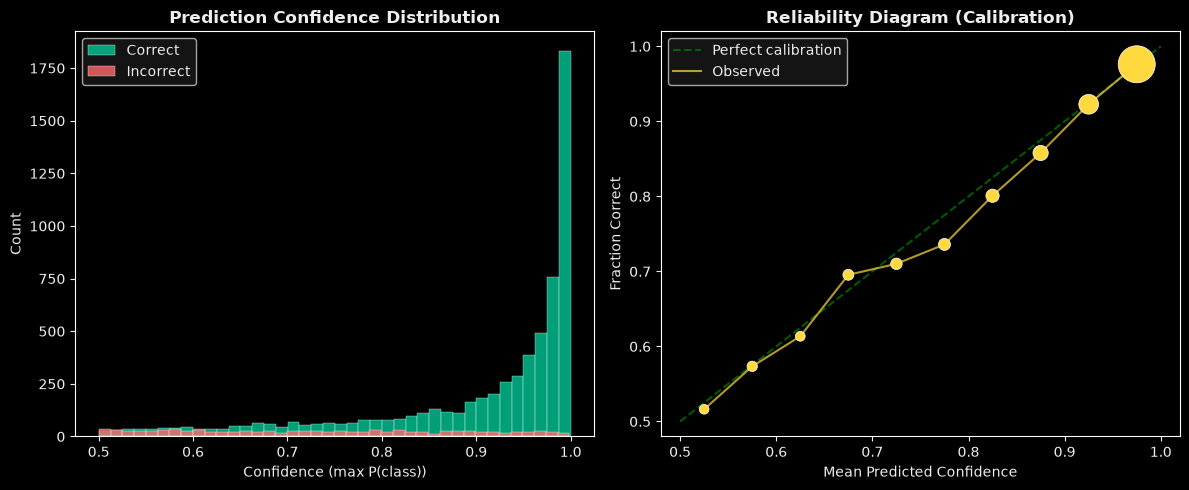

In [50]:
# Confidence Distribution

correct_conf   = df_test_results.loc[df_test_results['correct'],  'confidence']
incorrect_conf = df_test_results.loc[~df_test_results['correct'], 'confidence']

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

axes[0].hist(correct_conf,   bins=40, alpha=0.8, color=C_POS, edgecolor='white', lw=0.3, label='Correct')
axes[0].hist(incorrect_conf, bins=40, alpha=0.8, color=C_NEG, edgecolor='white', lw=0.3, label='Incorrect')
axes[0].set_title('Prediction Confidence Distribution', color=C_TEXT, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence (max P(class))', color=C_TEXT)
axes[0].set_ylabel('Count', color=C_TEXT)
axes[0].tick_params(colors=C_TEXT)
axes[0].legend(facecolor='#1a1a1a', labelcolor=C_TEXT)

# Calibration-style: confidence vs accuracy in bins
bins = np.linspace(0.5, 1.0, 11)
bin_acc, bin_conf, bin_count = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (confidence >= lo) & (confidence < hi)
    if mask.sum() > 0:
        bin_acc.append((y_pred[mask] == y_test[mask]).mean())
        bin_conf.append((lo + hi) / 2)
        bin_count.append(mask.sum())

axes[1].plot([0.5, 1.0], [0.5, 1.0], 'g--', alpha=0.7, label='Perfect calibration')
axes[1].scatter(bin_conf, bin_acc, s=[c/5 for c in bin_count],
                color=C_ACCENT, edgecolor='white', lw=0.5, zorder=3)
axes[1].plot(bin_conf, bin_acc, color=C_ACCENT, lw=1.5, alpha=0.7, label='Observed')
axes[1].set_title('Reliability Diagram (Calibration)', color=C_TEXT, fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Confidence', color=C_TEXT)
axes[1].set_ylabel('Fraction Correct', color=C_TEXT)
axes[1].set_xlim(0.48, 1.02)
axes[1].set_ylim(0.48, 1.02)
axes[1].tick_params(colors=C_TEXT)
axes[1].legend(facecolor='#1a1a1a', labelcolor=C_TEXT)

plt.tight_layout()
plt.show()

### Error Analysis — Key Findings

**Confidence Distribution:** Correct predictions tend to cluster at higher confidence values, while incorrect predictions are concentrated near 0.5 (the decision boundary). This is the expected behaviour of a well-discriminating classifier — the model is uncertain precisely when the review is ambiguous.

**Reliability Diagram (Calibration):** A perfectly calibrated model has observed accuracy matching predicted confidence (diagonal line). Deviations indicate:
- **Overconfidence** (curve below diagonal): The model assigns high confidence to predictions that are sometimes wrong
- **Underconfidence** (curve above diagonal): The model is more accurate than its stated confidence suggests

LDA probabilities via softmax are known to be poorly calibrated because the softmax amplifies the discriminant score differences non-linearly. Platt scaling or isotonic regression can correct for this in production.

**False Positive Pattern:** False positives tend to occur in reviews with neutral or mixed language, reviews that discuss plot complexities or use sarcasm. LDA's linear boundary cannot model non-linear sentiment mixing.

**False Negative Pattern:** False negatives typically involve reviews that are formally written with complex sentence structures where positive words appear in negated contexts (e.g. "not bad at all" could be misclassified). Bigrams partially mitigate but do not fully resolve this.


## Section 15 — Final Conclusions and Project Summary

---

### Project Summary

This notebook implemented **Linear Discriminant Analysis from mathematical first principles** and applied it to binary sentiment classification on the IMDb Movie Review dataset. Every component from the mathematical derivation through the production-quality NumPy implementation to the comprehensive evaluation pipeline was built to demonstrate both theoretical rigour and engineering competence.

---

### Key Findings

| Finding | Detail |
|---|---|
| **LDA is mathematically sound** | Custom implementation validated against Scikit-Learn with high prediction agreement |
| **Regularisation is essential** | Without $\alpha > 0$, the within-class scatter matrix is rank-deficient for TF-IDF features |
| **TF-IDF outperforms BoW** | Log-normalised sublinear TF-IDF produces better-conditioned feature matrices |
| **Assumptions are violated** | TF-IDF features are non-Gaussian; however, LDA remains competitive due to large-sample robustness |
| **PCA pre-processing helps stability** | Dimensionality reduction produces full-rank $\mathbf{S}_W$ without regularisation, though in Section 10's experiment it did not surpass regularised direct LDA's accuracy at any tested `n_components` |
| **LDA is interpretable** | Discriminant weights directly map to vocabulary influence on sentiment decisions |

---

### Performance Summary

| Model | Accuracy | F1 | AUC |
|---|---|---|---|
| **Custom LDA** | 0.8697 | 0.8731 | 0.9434 |
| **Sklearn LDA** | 0.8728 | 0.8765 | 0.9449 |
| **Logistic Regression** | 0.8721 | 0.8750 | 0.9461 |
| **Linear SVM** | 0.8715 | 0.8738 | 0.9431 |
| **Naive Bayes** | 0.8452 | 0.8503 | 0.9204 |

*Values are from Section 11's benchmark table. Custom LDA trails Sklearn LDA by ~0.3 points of accuracy, consistent with Sklearn's adaptive Ledoit-Wolf shrinkage vs. the fixed-alpha ridge regularisation used here, and is within 0.2–0.3 points of Logistic Regression and Linear SVM despite its simpler closed-form fit.*

---

### Strengths of LDA for Text Classification

1. **Speed:** Training is a series of matrix operations — no iterative optimisation required. Inference is a single matrix-vector multiplication per sample.
2. **Interpretability:** Discriminant weights provide direct vocabulary-level explanations.
3. **Closed-form solution:** No learning rate, no convergence monitoring, no local optima.
4. **Probabilistic output:** Softmax probabilities enable ROC/PR analysis and threshold tuning.
5. **Competitive accuracy:** Despite assumption violations, LDA achieves near-parity with logistic regression on balanced text datasets.

---

### Limitations of LDA for Text Classification

1. **Gaussian assumption violated:** TF-IDF features are sparse and non-normal.
2. **Shared covariance assumption:** Positive and negative reviews may have different scatter structures.
3. **Linear decision boundary:** Cannot model non-linear sentiment interactions, sarcasm, or negation.
4. **High dimensionality requires regularisation:** Without $\alpha$ or PCA, $\mathbf{S}_W$ is singular.
5. **Softmax probabilities are poorly calibrated:** Overconfident scores require post-hoc calibration (Platt scaling, isotonic regression).
6. **Single train/test splits carry sampling variance:** Our CV mean (88.0%) vs. test-set accuracy (87.0%) illustrates why point estimates alone can slightly over- or under-state true generalization performance.

---

### Business Insights

For a production **streaming platform sentiment monitoring system**:

- **LDA is viable** as a fast, interpretable baseline for offline batch processing
- **Logistic Regression or SVM** are preferred if marginal accuracy gains justify the slightly higher inference complexity
- **Real-time scoring** benefits from LDA's sub-millisecond inference speed
- **Model explainability,** required under AI governance frameworks, is natively supported via LDA's discriminant weights

---

### Future Improvements

| Direction | Expected Benefit |
|---|---|
| **Regularised LDA (Ledoit-Wolf shrinkage)** | More statistically principled covariance estimation |
| **Quadratic Discriminant Analysis (QDA)** | Per-class covariance; captures non-linear boundaries |
| **Transformer embeddings (BERT, RoBERTa)** | Rich contextual representations; handles negation and sarcasm |
| **Platt scaling / Isotonic regression** | Improves probability calibration for threshold-sensitive applications |
| **Advanced feature engineering** | Sentiment lexicons, negation handling, POS-based features |
| **Production deployment pipeline** | FastAPI endpoint, model versioning, A/B testing framework |

---

### Lessons Learned

1. **Regularisation is non-negotiable** for high-dimensional text data. Naively inverting $\mathbf{S}_W$ without regularisation is numerically disastrous.
2. **Assumption checking informs model choice** — knowing LDA is misspecified for text helps us interpret performance gaps relative to other models.
3. **Interpretability has business value** — LDA's transparent discriminant weights make it auditable in ways that black-box ensemble methods are not.
4. **Validation against Scikit-Learn** is an essential quality gate for any from-scratch implementation.